In [39]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load features (form + elo) and historical results (actual scores)
features = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])
results  = pd.read_csv('../data/processed/results_historical.csv', parse_dates=['date'])

# Merge to attach actual scores to each feature row
data = features.merge(
    results[['date', 'home_team', 'away_team', 'home_score', 'away_score']],
    on=['date', 'home_team', 'away_team'],
    how='left',
)

print(f"Feature rows:          {len(features):,}")
print(f"Rows with scores:      {data['home_score'].notna().sum():,}")
print(f"\nHome goals — mean: {data['home_score'].mean():.3f}  std: {data['home_score'].std():.3f}")
print(f"Away goals — mean: {data['away_score'].mean():.3f}  std: {data['away_score'].std():.3f}")
print(f"\nSample:")
print(data[['date','home_team','away_team','home_score','away_score','result']].head(4))

Feature rows:          16,610
Rows with scores:      16,610

Home goals — mean: 1.704  std: 1.724
Away goals — mean: 1.132  std: 1.331

Sample:
        date  home_team away_team  home_score  away_score    result
0 1916-07-02      Chile   Uruguay           0           4  away_win
1 1916-07-06  Argentina     Chile           6           1  home_win
2 1916-07-08     Brazil     Chile           1           1      draw
3 1916-07-10  Argentina    Brazil           1           1      draw


In [40]:
FEATURE_COLS = [
    'home_win_rate', 'home_draw_rate', 'home_avg_goals_scored', 'home_avg_goals_conceded',
    'away_win_rate', 'away_draw_rate', 'away_avg_goals_scored', 'away_avg_goals_conceded',
    'elo_diff', 'neutral', 'tournament',
]

RESULT_MAP     = {'home_win': 0, 'draw': 1, 'away_win': 2}
RESULT_MAP_INV = {0: 'home_win', 1: 'draw', 2: 'away_win'}

WC_2022_START = pd.Timestamp('2022-11-20')
WC_2026_START = pd.Timestamp('2026-06-11')

le_tournament = LabelEncoder()
le_tournament.fit(data['tournament'])

def encode_X(df):
    X = df[FEATURE_COLS].copy()
    X['neutral']    = X['neutral'].astype(int)
    X['tournament'] = le_tournament.transform(X['tournament'])
    return X

train = data[data['date'] < WC_2022_START].copy()
val   = data[
    (data['date'] >= WC_2022_START) &
    (data['date'] <  WC_2026_START) &
    (data['tournament'] == 'FIFA World Cup')
].copy()
test  = data[data['date'] >= WC_2026_START].copy()

X_train = encode_X(train)
X_val   = encode_X(val)
X_test  = encode_X(test)

print(f"Train: {len(train):,}  Val: {len(val)}  Test: {len(test)}")
print(f"\nTrain home goals: mean={train['home_score'].mean():.3f}")
print(f"Train away goals: mean={train['away_score'].mean():.3f}")

Train: 14,639  Val: 64  Test: 28

Train home goals: mean=1.713
Train away goals: mean=1.125


In [41]:
from sklearn.preprocessing import StandardScaler

# Features for each model reflect football logic:
# home goals = home attack + away defense weakness + context
# away goals = away attack + home defense weakness + context
FEATS_HOME = [
    'home_avg_goals_scored',   # home attack strength
    'away_avg_goals_conceded', # away defense weakness
    'home_win_rate',           # home form
    'elo_diff',                # overall quality gap
    'neutral',                 # home advantage removed if neutral
]
FEATS_AWAY = [
    'away_avg_goals_scored',   # away attack strength
    'home_avg_goals_conceded', # home defense weakness
    'away_win_rate',           # away form
    'elo_diff',
    'neutral',
]

# Scale features — PoissonRegressor is sensitive to feature magnitudes
scaler_home = StandardScaler()
scaler_away = StandardScaler()

X_train_h = scaler_home.fit_transform(train[FEATS_HOME])
X_train_a = scaler_away.fit_transform(train[FEATS_AWAY])
X_val_h   = scaler_home.transform(val[FEATS_HOME])
X_val_a   = scaler_away.transform(val[FEATS_AWAY])
X_test_h  = scaler_home.transform(test[FEATS_HOME])
X_test_a  = scaler_away.transform(test[FEATS_AWAY])

model_home = PoissonRegressor(alpha=0.01, max_iter=1000)
model_away = PoissonRegressor(alpha=0.01, max_iter=1000)

model_home.fit(X_train_h, train['home_score'])
model_away.fit(X_train_a, train['away_score'])

lam_home_val = model_home.predict(X_val_h)
lam_away_val = model_away.predict(X_val_a)

print("Predicted λ on WC 2022 validation:")
print(f"  λ_home: mean={lam_home_val.mean():.3f}  range=[{lam_home_val.min():.2f}, {lam_home_val.max():.2f}]")
print(f"  λ_away: mean={lam_away_val.mean():.3f}  range=[{lam_away_val.min():.2f}, {lam_away_val.max():.2f}]")
print(f"\nActual goals on WC 2022 validation:")
print(f"  home: mean={val['home_score'].mean():.3f}")
print(f"  away: mean={val['away_score'].mean():.3f}")

print("\nSample predictions:")
print(f"{'home_team':15} {'away_team':15} {'λ_home':>7} {'λ_away':>7} {'actual':>8}")
for i in range(6):
    row = val.iloc[i]
    print(f"{row['home_team']:15} {row['away_team']:15} {lam_home_val[i]:7.3f} {lam_away_val[i]:7.3f}  {row['home_score']:.0f}:{row['away_score']:.0f}")

Predicted λ on WC 2022 validation:
  λ_home: mean=1.391  range=[0.61, 2.49]
  λ_away: mean=1.197  range=[0.64, 2.56]

Actual goals on WC 2022 validation:
  home: mean=1.547
  away: mean=1.141

Sample predictions:
home_team       away_team        λ_home  λ_away   actual
Qatar           Ecuador           1.627   0.900  0:2
Senegal         Netherlands       1.028   1.597  0:2
England         Iran              1.334   1.203  6:2
USA             Wales             1.926   0.753  1:1
Argentina       Saudi Arabia      1.901   0.717  1:2
Mexico          Poland            1.804   0.815  0:0


In [42]:
def match_probabilities(lam_home, lam_away, max_goals=10):
    """Compute P(home_win), P(draw), P(away_win) from Poisson parameters."""
    p_home = p_draw = p_away = 0.0
    for i in range(max_goals + 1):
        for j in range(max_goals + 1):
            p = poisson.pmf(i, lam_home) * poisson.pmf(j, lam_away)
            if   i > j:  p_home += p
            elif i == j: p_draw += p
            else:        p_away += p
    return np.array([p_home, p_draw, p_away])

def get_probabilities(X_h, X_a, mh, ma):
    lam_h = mh.predict(X_h)
    lam_a = ma.predict(X_a)
    return np.array([match_probabilities(h, a) for h, a in zip(lam_h, lam_a)])

proba_val  = get_probabilities(X_val_h,  X_val_a,  model_home, model_away)
proba_test = get_probabilities(X_test_h, X_test_a, model_home, model_away)

print("Sample probabilities — WC 2022 validation:")
print(f"{'home_team':15} {'away_team':15} {'P(home)':>8} {'P(draw)':>8} {'P(away)':>8}  actual  score")
for i in range(8):
    row = val.iloc[i]
    p   = proba_val[i]
    print(f"{row['home_team']:15} {row['away_team']:15} {p[0]:8.3f} {p[1]:8.3f} {p[2]:8.3f}  {row['result']:9}  {row['home_score']:.0f}:{row['away_score']:.0f}")

print(f"\nMean P(draw) on val:  {proba_val[:, 1].mean():.3f}")
print(f"Mean P(draw) on test: {proba_test[:, 1].mean():.3f}")

Sample probabilities — WC 2022 validation:
home_team       away_team        P(home)  P(draw)  P(away)  actual  score
Qatar           Ecuador            0.545    0.247    0.208  away_win   0:2
Senegal         Netherlands        0.244    0.250    0.506  away_win   0:2
England         Iran               0.398    0.267    0.335  home_win   6:2
USA             Wales              0.651    0.211    0.138  draw       1:1
Argentina       Saudi Arabia       0.655    0.212    0.133  away_win   1:2
Mexico          Poland             0.609    0.226    0.165  draw       0:0
Denmark         Tunisia            0.355    0.284    0.361  draw       0:0
France          Australia          0.626    0.221    0.152  home_win   4:1

Mean P(draw) on val:  0.244
Mean P(draw) on test: 0.228


In [43]:
LABELS = ['home_win', 'draw', 'away_win']

def evaluate(name, proba, y_true_str):
    y_true   = y_true_str.map(RESULT_MAP).values
    y_pred   = np.argmax(proba, axis=1)
    acc      = accuracy_score(y_true, y_pred)
    ll       = log_loss(y_true, proba, labels=[0, 1, 2])
    baseline = max(y_true_str.value_counts(normalize=True))

    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f}  (baseline: {baseline:.3f})")
    print(f"Log loss: {ll:.4f}  (random 3-class: 1.0986)")
    print()
    print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(pd.DataFrame(
        confusion_matrix(y_true, y_pred),
        index=LABELS, columns=LABELS,
    ))
    print()

evaluate("Validation — WC 2022", proba_val,  val['result'])
evaluate("Test       — WC 2026", proba_test, test['result'])

=== Validation — WC 2022 ===
Accuracy: 0.516  (baseline: 0.438)
Log loss: 1.0307  (random 3-class: 1.0986)

              precision    recall  f1-score   support

    home_win       0.56      0.79      0.66        28
        draw       0.00      0.00      0.00        15
    away_win       0.44      0.52      0.48        21

    accuracy                           0.52        64
   macro avg       0.33      0.44      0.38        64
weighted avg       0.39      0.52      0.44        64

Confusion matrix (rows=actual, cols=predicted):
          home_win  draw  away_win
home_win        22     0         6
draw             7     0         8
away_win        10     0        11

=== Test       — WC 2026 ===
Accuracy: 0.500  (baseline: 0.536)
Log loss: 0.9798  (random 3-class: 1.0986)

              precision    recall  f1-score   support

    home_win       0.65      0.73      0.69        15
        draw       0.00      0.00      0.00        10
    away_win       0.27      1.00      0.43        

In [44]:
import pickle

with open('../models/xgb_model.pkl', 'rb') as f:
    art = pickle.load(f)

xgb_model = art['model']
xgb_le    = art['le_tournament']

def encode_X_xgb(df):
    X = df[art['feature_cols']].copy()
    X['neutral']    = X['neutral'].astype(int)
    X['tournament'] = xgb_le.transform(X['tournament'])
    return X

proba_xgb_val  = xgb_model.predict_proba(encode_X_xgb(val))
proba_xgb_test = xgb_model.predict_proba(encode_X_xgb(test))

print("=" * 58)
print(f"{'Метрика':<28} {'XGBoost':>12} {'Poisson':>12}")
print("=" * 58)

for label, y_str, p_xgb, p_poi in [
    ("Val log loss",  val['result'],  proba_xgb_val,  proba_val),
    ("Test log loss", test['result'], proba_xgb_test, proba_test),
]:
    y   = y_str.map(RESULT_MAP).values
    lx  = log_loss(y, p_xgb, labels=[0,1,2])
    lp  = log_loss(y, p_poi,  labels=[0,1,2])
    win = "← Poisson" if lp < lx else "← XGBoost"
    print(f"{label:<28} {lx:>12.4f} {lp:>12.4f}  {win}")

for label, y_str, p_xgb, p_poi in [
    ("Val accuracy",  val['result'],  proba_xgb_val,  proba_val),
    ("Test accuracy", test['result'], proba_xgb_test, proba_test),
]:
    y    = y_str.map(RESULT_MAP).values
    ax   = accuracy_score(y, np.argmax(p_xgb, axis=1))
    ap   = accuracy_score(y, np.argmax(p_poi,  axis=1))
    win  = "← Poisson" if ap > ax else "← XGBoost"
    print(f"{label:<28} {ax:>12.3f} {ap:>12.3f}  {win}")

print("-" * 58)

for label, y_str, p_xgb, p_poi in [
    ("Val draws predicted",  val['result'],  proba_xgb_val,  proba_val),
    ("Test draws predicted", test['result'], proba_xgb_test, proba_test),
]:
    actual    = (y_str == 'draw').sum()
    draws_xgb = (np.argmax(p_xgb, axis=1) == 1).sum()
    draws_poi = (np.argmax(p_poi,  axis=1) == 1).sum()
    print(f"{label:<28} {draws_xgb:>12} {draws_poi:>12}   (actual: {actual})")

print("=" * 58)

Метрика                           XGBoost      Poisson
Val log loss                       1.0189       1.0307  ← XGBoost
Test log loss                      0.9843       0.9798  ← Poisson
Val accuracy                        0.469        0.516  ← Poisson
Test accuracy                       0.536        0.500  ← XGBoost
----------------------------------------------------------
Val draws predicted                     0            0   (actual: 15)
Test draws predicted                    0            0   (actual: 10)


In [45]:
proba_ens_val  = (proba_xgb_val  + proba_val)  / 2
proba_ens_test = (proba_xgb_test + proba_test) / 2

print("=" * 65)
print(f"{'Metric':<28} {'XGBoost':>10} {'Poisson':>10} {'Ensemble':>10}")
print("=" * 65)

for label, y_str, p_xgb, p_poi, p_ens in [
    ("Val log loss",  val['result'],  proba_xgb_val,  proba_val,  proba_ens_val),
    ("Test log loss", test['result'], proba_xgb_test, proba_test, proba_ens_test),
]:
    y   = y_str.map(RESULT_MAP).values
    lx  = log_loss(y, p_xgb, labels=[0,1,2])
    lp  = log_loss(y, p_poi,  labels=[0,1,2])
    le  = log_loss(y, p_ens,  labels=[0,1,2])
    best = min(lx, lp, le)
    print(f"{label:<28} {lx:>10.4f} {lp:>10.4f} {le:>10.4f}  {'✅' if le == best else ''}")

for label, y_str, p_xgb, p_poi, p_ens in [
    ("Val accuracy",  val['result'],  proba_xgb_val,  proba_val,  proba_ens_val),
    ("Test accuracy", test['result'], proba_xgb_test, proba_test, proba_ens_test),
]:
    y    = y_str.map(RESULT_MAP).values
    ax   = accuracy_score(y, np.argmax(p_xgb, axis=1))
    ap   = accuracy_score(y, np.argmax(p_poi,  axis=1))
    ae   = accuracy_score(y, np.argmax(p_ens,  axis=1))
    best = max(ax, ap, ae)
    print(f"{label:<28} {ax:>10.3f} {ap:>10.3f} {ae:>10.3f}  {'✅' if ae == best else ''}")

print("-" * 65)

for label, y_str, p_xgb, p_poi, p_ens in [
    ("Val draws predicted",  val['result'],  proba_xgb_val,  proba_val,  proba_ens_val),
    ("Test draws predicted", test['result'], proba_xgb_test, proba_test, proba_ens_test),
]:
    actual    = (y_str == 'draw').sum()
    dx = (np.argmax(p_xgb, axis=1) == 1).sum()
    dp = (np.argmax(p_poi,  axis=1) == 1).sum()
    de = (np.argmax(p_ens,  axis=1) == 1).sum()
    print(f"{label:<28} {dx:>10} {dp:>10} {de:>10}   (actual: {actual})")

print("=" * 65)

print("\nEnsemble P(draw) distribution on val:")
draw_probs = proba_ens_val[:, 1]
print(f"  mean={draw_probs.mean():.3f}  max={draw_probs.max():.3f}  min={draw_probs.min():.3f}")

# Show val matches where P(draw) is highest in ensemble
val_with_draw = val.copy().reset_index(drop=True)
val_with_draw['p_draw_ens'] = proba_ens_val[:, 1]
val_with_draw['p_home_ens'] = proba_ens_val[:, 0]
val_with_draw['p_away_ens'] = proba_ens_val[:, 2]
top_draws = val_with_draw.nlargest(8, 'p_draw_ens')
print(f"\nTop 8 matches by P(draw) — ensemble:")
print(f"{'home':15} {'away':15} {'P(home)':>8} {'P(draw)':>8} {'P(away)':>8}  actual  score")
for _, r in top_draws.iterrows():
    print(f"{r['home_team']:15} {r['away_team']:15} {r['p_home_ens']:8.3f} {r['p_draw_ens']:8.3f} {r['p_away_ens']:8.3f}  {r['result']:9}  {r['home_score']:.0f}:{r['away_score']:.0f}")

Metric                          XGBoost    Poisson   Ensemble
Val log loss                     1.0189     1.0307     1.0188  ✅
Test log loss                    0.9843     0.9798     0.9796  ✅
Val accuracy                      0.469      0.516      0.500  
Test accuracy                     0.536      0.500      0.500  
-----------------------------------------------------------------
Val draws predicted                   0          0          0   (actual: 15)
Test draws predicted                  0          0          0   (actual: 10)

Ensemble P(draw) distribution on val:
  mean=0.248  max=0.292  min=0.164

Top 8 matches by P(draw) — ensemble:
home            away             P(home)  P(draw)  P(away)  actual  score
Denmark         Tunisia            0.364    0.292    0.344  draw       0:0
Japan           Croatia            0.373    0.290    0.337  draw       1:1
Tunisia         Australia          0.412    0.289    0.299  away_win   0:1
Saudi Arabia    Mexico             0.297    0.286

In [46]:
from pathlib import Path

Path('../models').mkdir(exist_ok=True)

artifact = {
    'model_home':    model_home,
    'model_away':    model_away,
    'scaler_home':   scaler_home,
    'scaler_away':   scaler_away,
    'feats_home':    FEATS_HOME,
    'feats_away':    FEATS_AWAY,
    'result_map':    RESULT_MAP,
    'result_map_inv': RESULT_MAP_INV,
}

with open('../models/poisson_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print("Saved: models/poisson_model.pkl")
print(f"Contents: {list(artifact.keys())}")

Saved: models/poisson_model.pkl
Contents: ['model_home', 'model_away', 'scaler_home', 'scaler_away', 'feats_home', 'feats_away', 'result_map', 'result_map_inv']


=== Calibration Report — Ensemble (val + test, 92 matches) ===

Class         Brier score  Interpretation
-------------------------------------------------------
home_win           0.2236  (baseline naive: 0.2489)
draw               0.1977  (baseline naive: 0.1979)
away_win           0.1779  (baseline naive: 0.1928)


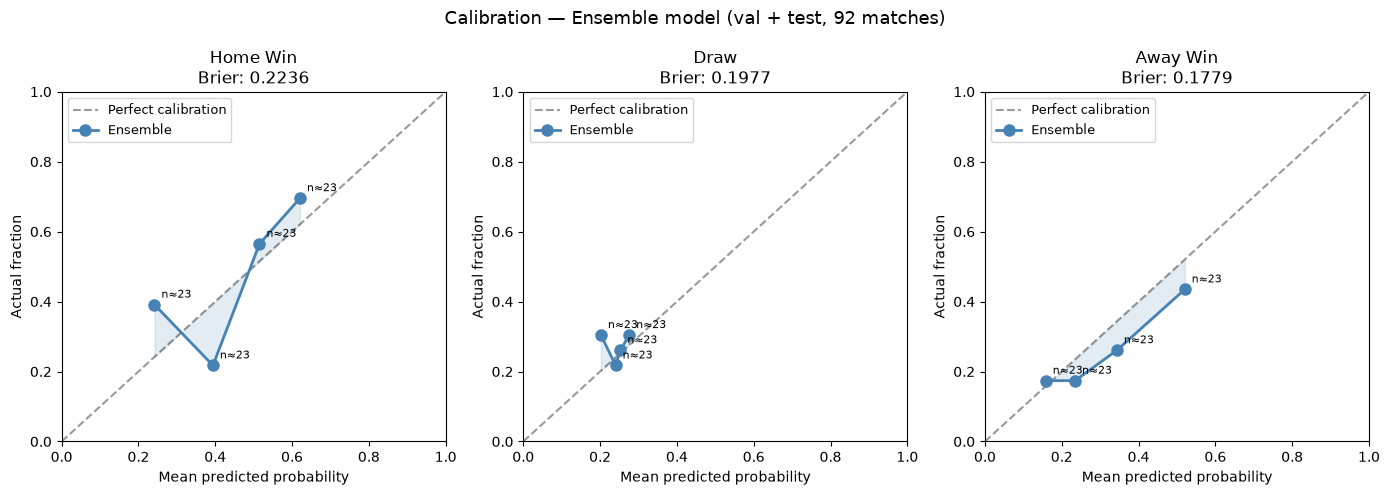


Saved: docs/assets/calibration_plot.png

=== Expected Calibration Error (ECE) per class ===
  home_win    : ECE = 0.0454  (0 = perfect, 0.5 = worst)
  draw        : ECE = 0.0289  (0 = perfect, 0.5 = worst)
  away_win    : ECE = 0.0534  (0 = perfect, 0.5 = worst)


In [48]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Combine val + test for more data (92 matches total)
y_all_str  = pd.concat([val['result'], test['result']]).reset_index(drop=True)
proba_all  = np.vstack([proba_ens_val, proba_ens_test])

LABELS = ['home_win', 'draw', 'away_win']
CLASS_NAMES = {'home_win': 'Home Win', 'draw': 'Draw', 'away_win': 'Away Win'}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Calibration — Ensemble model (val + test, 92 matches)', fontsize=13)

print("=== Calibration Report — Ensemble (val + test, 92 matches) ===\n")
print(f"{'Class':<12} {'Brier score':>12}  {'Interpretation'}")
print("-" * 55)

for idx, label in enumerate(LABELS):
    # Binary: was this class the actual outcome?
    y_bin   = (y_all_str == label).astype(int).values
    p_class = proba_all[:, idx]

    # Brier score: mean squared error of probabilities (lower = better, 0 = perfect)
    brier = brier_score_loss(y_bin, p_class)
    baseline_brier = brier_score_loss(y_bin, np.full_like(p_class, y_bin.mean()))
    print(f"{label:<12} {brier:>12.4f}  (baseline naive: {baseline_brier:.4f})")

    # Reliability diagram — 4 bins (92 matches is small, fewer bins = more stable)
    try:
        fraction_pos, mean_pred = calibration_curve(y_bin, p_class, n_bins=4, strategy='quantile')
        ax = axes[idx]
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
        ax.plot(mean_pred, fraction_pos, 'o-', color='steelblue', linewidth=2, markersize=8, label='Ensemble')
        ax.fill_between(mean_pred, fraction_pos, mean_pred,
                        alpha=0.15, color='steelblue')
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Actual fraction')
        ax.set_title(f'{CLASS_NAMES[label]}\nBrier: {brier:.4f}')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        # Annotate each point with sample count
        counts, _ = np.histogram(p_class, bins=4)
        for x, y in zip(mean_pred, fraction_pos):
            ax.annotate(f'n≈{len(p_class)//4}', (x, y),
                       textcoords='offset points', xytext=(5, 5), fontsize=8)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Not enough data\n{e}', ha='center', va='center')

plt.tight_layout()
plt.savefig('../docs/assets/calibration_plot.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nSaved: docs/assets/calibration_plot.png")

# ECE — Expected Calibration Error (weighted average miscalibration across bins)
print("\n=== Expected Calibration Error (ECE) per class ===")
n_bins = 4
for idx, label in enumerate(LABELS):
    y_bin   = (y_all_str == label).astype(int).values
    p_class = proba_all[:, idx]
    bins    = np.linspace(0, 1, n_bins + 1)
    ece     = 0.0
    for i in range(n_bins):
        mask = (p_class >= bins[i]) & (p_class < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_bin[mask].mean()
        conf = p_class[mask].mean()
        ece += (mask.sum() / len(y_bin)) * abs(acc - conf)
    print(f"  {label:<12}: ECE = {ece:.4f}  (0 = perfect, 0.5 = worst)")